#Importación de datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import NoReturn

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de datos
Ingreso total de cada tienda

In [2]:
def ingresoTotal(tienda : pd.DataFrame) -> float:
  return tienda["Precio"].sum()

In [3]:
ingresoTotalTienda1 = ingresoTotal(tienda)
print(f'El ingreso total de la tienda 1 es de: ${ingresoTotalTienda1}')
ingresoTotalTienda2 = ingresoTotal(tienda2)
print(f'El ingreso total de la tienda 2 es de: ${ingresoTotalTienda2}')
ingresoTotalTienda3 = ingresoTotal(tienda3)
print(f'El ingreso total de la tienda 3 es de: ${ingresoTotalTienda3}')
ingresoTotalTienda4 = ingresoTotal(tienda4)
print(f'El ingreso total de la tienda 4 es de: ${ingresoTotalTienda4}')

El ingreso total de la tienda 1 es de: $1150880400.0
El ingreso total de la tienda 2 es de: $1116343500.0
El ingreso total de la tienda 3 es de: $1098019600.0
El ingreso total de la tienda 4 es de: $1038375700.0


In [4]:
#Se definen los colores para el gráfico
colores = ['cyan', 'red', 'darkgreen', 'coral']

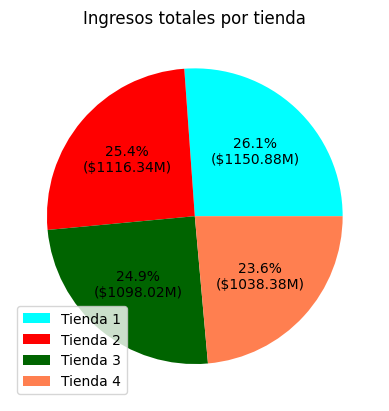

In [5]:
Ingresos = pd.DataFrame( columns= ['Ingreso Total en Millones', 'Tienda'])
Ingresos['Ingreso Total en Millones'] = [ingresoTotalTienda1*1e-6, ingresoTotalTienda2*1e-6, ingresoTotalTienda3*1e-6, ingresoTotalTienda4*1e-6]
Ingresos['Tienda'] = ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']
ax = Ingresos.plot(y='Ingreso Total en Millones',
                   kind='pie',autopct=lambda pct: f"{pct:.1f}%\n(${ (pct/100 * Ingresos['Ingreso Total en Millones'].sum()):.2f}M)",
                   labels = None, colors = colores)
ax.set_ylabel('')
ax.set_title('Ingresos totales por tienda')
ax.legend(labels=Ingresos['Tienda'])
plt.gcf().savefig('Ingresos.png')

#2. Ventas por categoría

In [6]:
def ventasPorCategoria(tienda : pd.DataFrame) -> pd.Series:
    productosPorCategoria = tienda["Categoría del Producto"].value_counts()
    productosPorCategoria.sort_values(ascending=True)
    return productosPorCategoria

VentasPorCategoriaTienda1 = ventasPorCategoria(tienda)
print(f'Tienda 1:\nProductos por categoria\n{VentasPorCategoriaTienda1}')
VentasPorCategoriaTienda2 = ventasPorCategoria(tienda2)
print('*'*50)
print(f'Tienda 2:\nProductos por categoria\n{VentasPorCategoriaTienda2}')
VentasPorCategoriaTienda3 = ventasPorCategoria(tienda3)
print('*'*50)
print(f'Tienda 3:\nProductos por categoria\n{VentasPorCategoriaTienda3}')
VentasPorCategoriaTienda4 = ventasPorCategoria(tienda4)
print('*'*50)
print(f'Tienda 4:\nProductos por categoria\n{VentasPorCategoriaTienda4}')

Tienda 1:
Productos por categoria
Categoría del Producto
Muebles                    465
Electrónicos               448
Juguetes                   324
Electrodomésticos          312
Deportes y diversión       284
Instrumentos musicales     182
Libros                     173
Artículos para el hogar    171
Name: count, dtype: int64
**************************************************
Tienda 2:
Productos por categoria
Categoría del Producto
Muebles                    442
Electrónicos               422
Juguetes                   313
Electrodomésticos          305
Deportes y diversión       275
Instrumentos musicales     224
Libros                     197
Artículos para el hogar    181
Name: count, dtype: int64
**************************************************
Tienda 3:
Productos por categoria
Categoría del Producto
Muebles                    499
Electrónicos               451
Juguetes                   315
Electrodomésticos          278
Deportes y diversión       277
Libros                  

In [7]:
#Acá se listan los productos más y menos populares de cada tienda
print(f'Los productos mas populares en la Tienda 1 son:\n{VentasPorCategoriaTienda1.head()}')
print('*'*50)
print(f'Los productos mas populares en la Tienda 2 son:\n{VentasPorCategoriaTienda2.head()}')
print('*'*50)
print(f'Los productos mas populares en la Tienda 3 son:\n{VentasPorCategoriaTienda3.head()}')
print('*'*50)
print(f'Los productos mas populares en la Tienda 4 son:\n{VentasPorCategoriaTienda4.head()}')
print('*'*50)
#----------------------------------------------------------
print(f'Los productos menos populares en la Tienda 1 son:\n{VentasPorCategoriaTienda1.tail()}')
print('*'*50)
print(f'Los productos menos populares en la Tienda 2 son:\n{VentasPorCategoriaTienda2.tail()}')
print('*'*50)
print(f'Los productos menos populares en la Tienda 3 son:\n{VentasPorCategoriaTienda3.tail()}')
print('*'*50)
print(f'Los productos menos populares en la Tienda 4 son:\n{VentasPorCategoriaTienda4.tail()}')
print('*'*50)

Los productos mas populares en la Tienda 1 son:
Categoría del Producto
Muebles                 465
Electrónicos            448
Juguetes                324
Electrodomésticos       312
Deportes y diversión    284
Name: count, dtype: int64
**************************************************
Los productos mas populares en la Tienda 2 son:
Categoría del Producto
Muebles                 442
Electrónicos            422
Juguetes                313
Electrodomésticos       305
Deportes y diversión    275
Name: count, dtype: int64
**************************************************
Los productos mas populares en la Tienda 3 son:
Categoría del Producto
Muebles                 499
Electrónicos            451
Juguetes                315
Electrodomésticos       278
Deportes y diversión    277
Name: count, dtype: int64
**************************************************
Los productos mas populares en la Tienda 4 son:
Categoría del Producto
Muebles                 480
Electrónicos            451
Juguetes 

In [8]:
VentasPorCategoria = {'Tienda 1': VentasPorCategoriaTienda1,
                      'Tienda 2': VentasPorCategoriaTienda2,
                      'Tienda 3': VentasPorCategoriaTienda3,
                      'Tienda 4': VentasPorCategoriaTienda3}

VentasPorCategoria = pd.DataFrame(VentasPorCategoria)

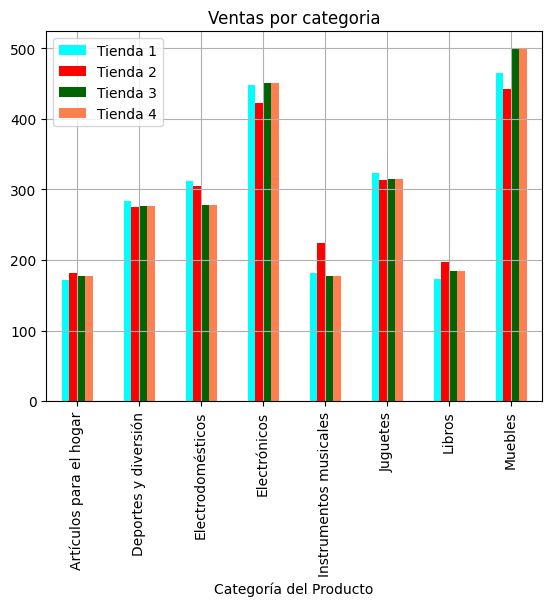

In [9]:
ax = VentasPorCategoria.plot(kind='bar', title='Ventas por categoria', color = colores)
ax.grid()
ax.patches
plt.gcf().savefig('VentasPorCategoria.png')

#3. Calificación promedio de la tienda

In [10]:
def calificacionPromedio(tienda : pd.DataFrame) -> float:
  return tienda["Calificación"].mean()

calificacionPromedioTienda1 = calificacionPromedio(tienda)
print(f'La calificacion promedio de la tienda 1 es de: {calificacionPromedioTienda1: .2f}/5')
calificacionPromedioTienda2 = calificacionPromedio(tienda2)
print(f'La calificacion promedio de la tienda 2 es de: {calificacionPromedioTienda2: .2f}/5')
calificacionPromedioTienda3 = calificacionPromedio(tienda3)
print(f'La calificacion promedio de la tienda 3 es de: {calificacionPromedioTienda3: .2f}/5')
calificacionPromedioTienda4 = calificacionPromedio(tienda4)
print(f'La calificacion promedio de la tienda 4 es de: {calificacionPromedioTienda4: .2f}/5')

La calificacion promedio de la tienda 1 es de:  3.98/5
La calificacion promedio de la tienda 2 es de:  4.04/5
La calificacion promedio de la tienda 3 es de:  4.05/5
La calificacion promedio de la tienda 4 es de:  4.00/5


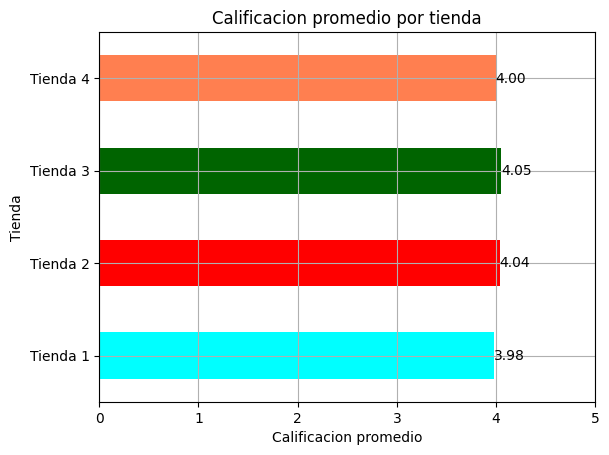

In [11]:
calificacionPromedio = pd.DataFrame({'Calificacion Promedio': [calificacionPromedioTienda1, calificacionPromedioTienda2, calificacionPromedioTienda3, calificacionPromedioTienda4],
                                     'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']})
ax = calificacionPromedio.plot(x='Tienda', y='Calificacion Promedio', kind = 'barh', title= 'Calificacion promedio por tienda', grid = True, xlim = (0,5), legend = False, xlabel = 'Calificacion promedio', color = colores)
# Procedemos a indicar la calificacion promedio en el grafico
[ax.text(value, index, f'{value:.2f}', va='center', ha='left') for index, value in enumerate(calificacionPromedio['Calificacion Promedio'])]
plt.gcf().savefig('CalificacionPromedio.png')

#4. Productos más y menos vendidos

In [12]:
def productosMasVendidos(tienda : pd.DataFrame) -> pd.Series:
  productosVendidos = tienda["Producto"].value_counts().sort_values(ascending=False)
  ventasMax = productosVendidos.max()
  productoMasVendido = productosVendidos[productosVendidos == ventasMax]
  return productoMasVendido

def productosMenosVendidos(tienda : pd.DataFrame) -> pd.Series:
  productosVendidos = tienda["Producto"].value_counts().sort_values(ascending=False)
  ventasMin = productosVendidos.min()
  productoMenosVendido = productosVendidos[productosVendidos == ventasMin]
  return productoMenosVendido

#Muestar el producto(s) mas veniddo
productoMasVendidoTienda1 = productosMasVendidos(tienda)
print(f'El producto(s) mas vendido en la tienda 1 es:\n{productoMasVendidoTienda1}')
productoMasVendidoTienda2 = productosMasVendidos(tienda2)
print('*'*50)
print(f'El producto(s) mas vendido en la tienda 2 es:\n{productoMasVendidoTienda2}')
productoMasVendidoTienda3 = productosMasVendidos(tienda3)
print('*'*50)
print(f'El producto(s) mas vendido en la tienda 3 es:\n{productoMasVendidoTienda3}')
productoMasVendidoTienda4 = productosMasVendidos(tienda4)
print('*'*50)
print(f'El producto(s) mas vendido en la tienda 4 es:\n{productoMasVendidoTienda4}')
#Muestar el producto(s) menos veniddo
productoMenosVendidoTienda1 = productosMenosVendidos(tienda)
print(f'El producto(s) menos vendido en la tienda 1 es:\n{productoMenosVendidoTienda1}')
print('*'*50)
productoMenosVendidoTienda2 = productosMenosVendidos(tienda2)
print('*'*50)
print(f'El producto(s) menos vendido en la tienda 2 es:\n{productoMenosVendidoTienda2}')
productoMenosVendidoTienda3 = productosMenosVendidos(tienda3)
print('*'*50)
print(f'El producto(s) menos vendido en la tienda 3 es:\n{productoMenosVendidoTienda3}')
productoMenosVendidoTienda4 = productosMenosVendidos(tienda4)
print('*'*50)
print(f'El producto(s) menos vendido en la tienda 4 es:\n{productoMenosVendidoTienda4}')

El producto(s) mas vendido en la tienda 1 es:
Producto
Microondas       60
TV LED UHD 4K    60
Armario          60
Name: count, dtype: int64
**************************************************
El producto(s) mas vendido en la tienda 2 es:
Producto
Iniciando en programación    65
Name: count, dtype: int64
**************************************************
El producto(s) mas vendido en la tienda 3 es:
Producto
Kit de bancas    57
Name: count, dtype: int64
**************************************************
El producto(s) mas vendido en la tienda 4 es:
Producto
Cama box    62
Name: count, dtype: int64
El producto(s) menos vendido en la tienda 1 es:
Producto
Auriculares con micrófono    33
Celular ABXY                 33
Name: count, dtype: int64
**************************************************
**************************************************
El producto(s) menos vendido en la tienda 2 es:
Producto
Juego de mesa    32
Name: count, dtype: int64
********************************************

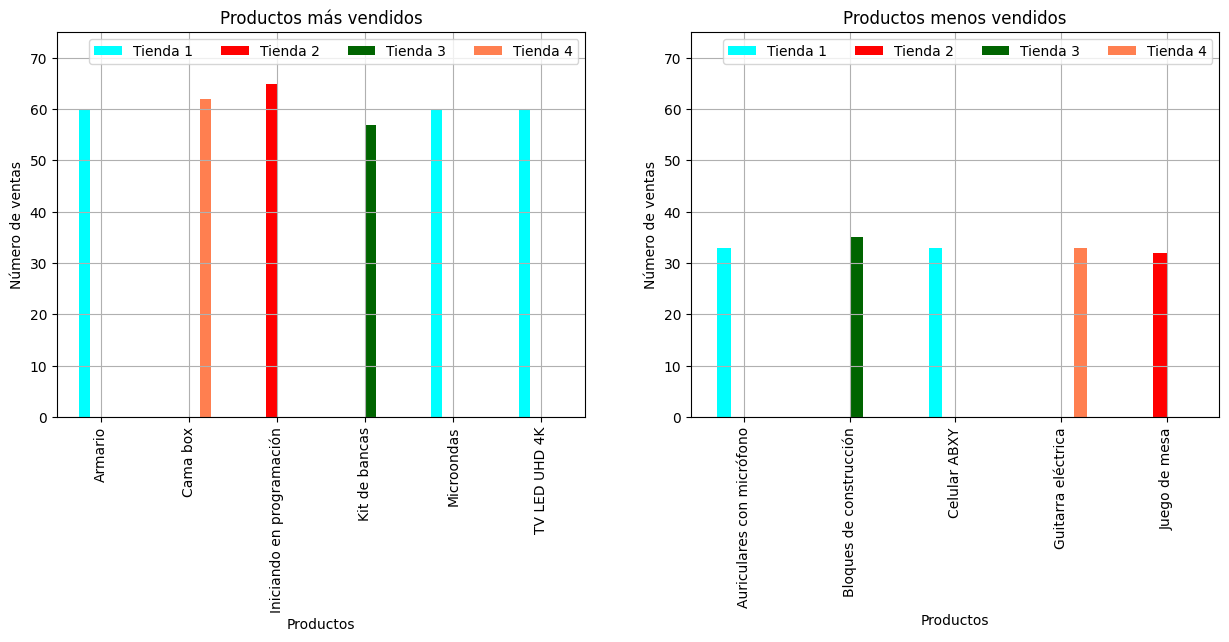

In [13]:
productosMasVendidos = {'Tienda 1': productoMasVendidoTienda1,
                        'Tienda 2': productoMasVendidoTienda2,
                        'Tienda 3': productoMasVendidoTienda3,
                        'Tienda 4': productoMasVendidoTienda4}

productosMasVendidos = pd.DataFrame(productosMasVendidos)
fig, (axl, axr) = plt.subplots(ncols = 2, figsize = (15,5))
axl = productosMasVendidos.plot(ax = axl, kind='bar', title='Productos más vendidos', xlabel='Productos', ylabel='Número de ventas', grid = True, color = colores)
axl.legend(ncols = 4)
#Ajustamos los valores
axl.set_ylim(0, axl.get_ylim()[1]*1.1)
productosMenosVendidos = {'Tienda 1': productoMenosVendidoTienda1,
                          'Tienda 2': productoMenosVendidoTienda2,
                          'Tienda 3': productoMenosVendidoTienda3,
                          'Tienda 4': productoMenosVendidoTienda4}

productosMenosVendidos = pd.DataFrame(productosMenosVendidos)
axr = productosMenosVendidos.plot(ax = axr, kind='bar', title='Productos menos vendidos', xlabel='Productos', ylabel='Número de ventas', grid = True, color = colores)
axr.legend(ncols = 4)

axr.set_ylim(0, axl.get_ylim()[1])
plt.gcf().savefig('ProductosMasyMenosVendidos.png')

#5. Envío promedio por tienda

In [14]:
def gastoPromedioEnvio(tienda : pd.DataFrame) -> float:
  return tienda["Costo de envío"].mean()
envioPromedioTienda1 = gastoPromedioEnvio(tienda)
print(f'El costo promedio de envio de la tienda 1 fue de: ${envioPromedioTienda1: .2f}')
envioPromedioTienda2 = gastoPromedioEnvio(tienda2)
print(f'El costo promedio de envio de la tienda 2 fue de: ${envioPromedioTienda2: .2f}')
envioPromedioTienda3 = gastoPromedioEnvio(tienda3)
print(f'El costo promedio de envio de la tienda 3 fue de: ${envioPromedioTienda3: .2f}')
envioPromedioTienda4 = gastoPromedioEnvio(tienda4)
print(f'El costo promedio de envio de la tienda 4 fue de: ${envioPromedioTienda4: .2f}')

El costo promedio de envio de la tienda 1 fue de: $ 26018.61
El costo promedio de envio de la tienda 2 fue de: $ 25216.24
El costo promedio de envio de la tienda 3 fue de: $ 24805.68
El costo promedio de envio de la tienda 4 fue de: $ 23459.46


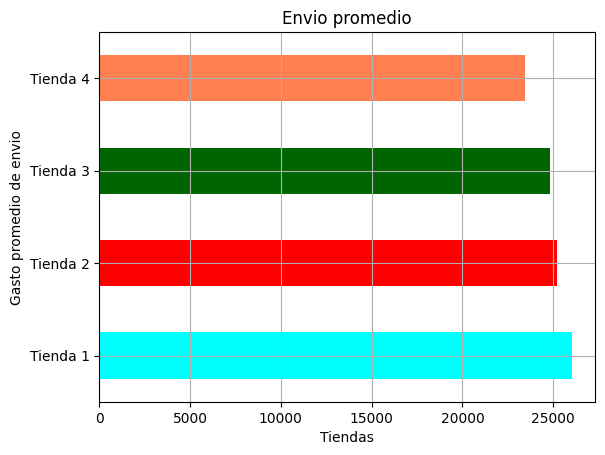

In [15]:
envioPromedio = pd.DataFrame({'Envio Promedio': [envioPromedioTienda1 , envioPromedioTienda2, envioPromedioTienda3, envioPromedioTienda4],
                              'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4']})

envioPromedio.plot(x = 'Tienda', y = 'Envio Promedio', kind='barh', title='Envio promedio', xlabel='Tiendas', ylabel='Gasto promedio de envio', grid = True, legend = False, color = colores)
plt.gcf().savefig('EnvioPromedio.png')

#Informe Final

###Metodología de Evaluación
Para garantizar una perspectiva objetiva, se evaluaron diversos indicadores clave de rendimiento (KPIs) mediante una escala de puntuación del 1 al 4, donde 4 representa el desempeño óptimo. En situaciones de empate, se aplicó un criterio de asignación descendente; por ejemplo, si tres tiendas comparten el liderazgo, se les asigna una puntuación de 2, reservando el 1 para el desempeño inferior.

1. Análisis de Facturación e Ingresos
En términos de recaudación total, la Tienda 1 se posiciona como el punto de venta con mayor generación de ingresos. Por el contrario, la Tienda 4 registra el volumen de facturación más bajo del periodo analizado.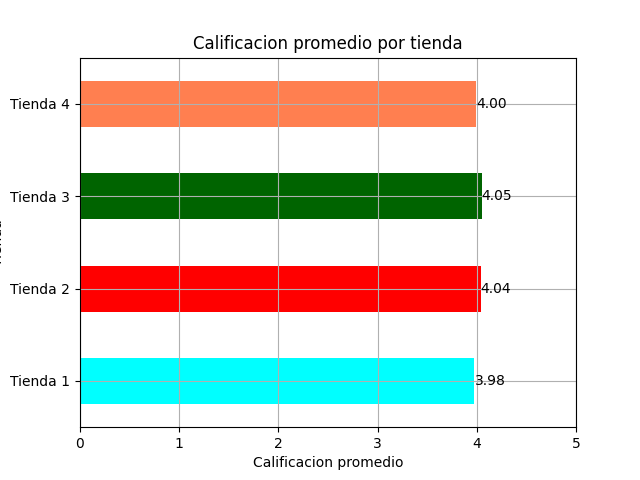


2. Rendimiento por Categoría de Producto
Las categorías de Electrónica y Muebles lideran el volumen de ventas general. En ambos segmentos, la Tienda 3 muestra el desempeño más rezagado, situándose por debajo del promedio de sus homólogas.

3. Satisfacción y Evaluación del Cliente
Tras promediar las valoraciones otorgadas por los usuarios, la Tienda 2 destaca con los índices de satisfacción más altos. En el extremo opuesto, la Tienda 1 se identifica como la unidad con mayor área de oportunidad, requiriendo estrategias de mejora en la experiencia del cliente.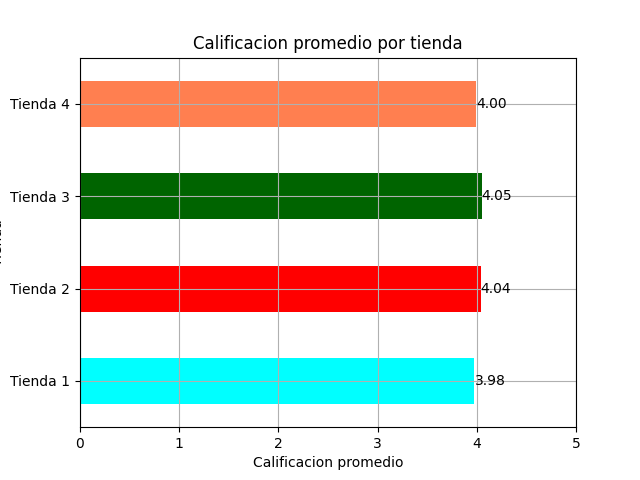

4. Análisis de Productos Críticos (Máximos y Mínimos)
Se realizó un comparativo de los artículos con mayor y menor rotación:

Liderazgo en ventas: La Tienda 3 sobresale con el producto "Iniciando en programación" (65 unidades), superando al "Kit de bancas" de la misma sucursal (57 unidades).

Volúmenes mínimos: No se detectan variaciones significativas entre tiendas, manteniendo una tendencia uniforme.

Diversificación: Es relevante destacar que la Tienda 1 presenta múltiples empates en sus niveles máximos y mínimos de ventas, lo que sugiere una cartera de productos más diversificada y un riesgo de ingresos más distribuido.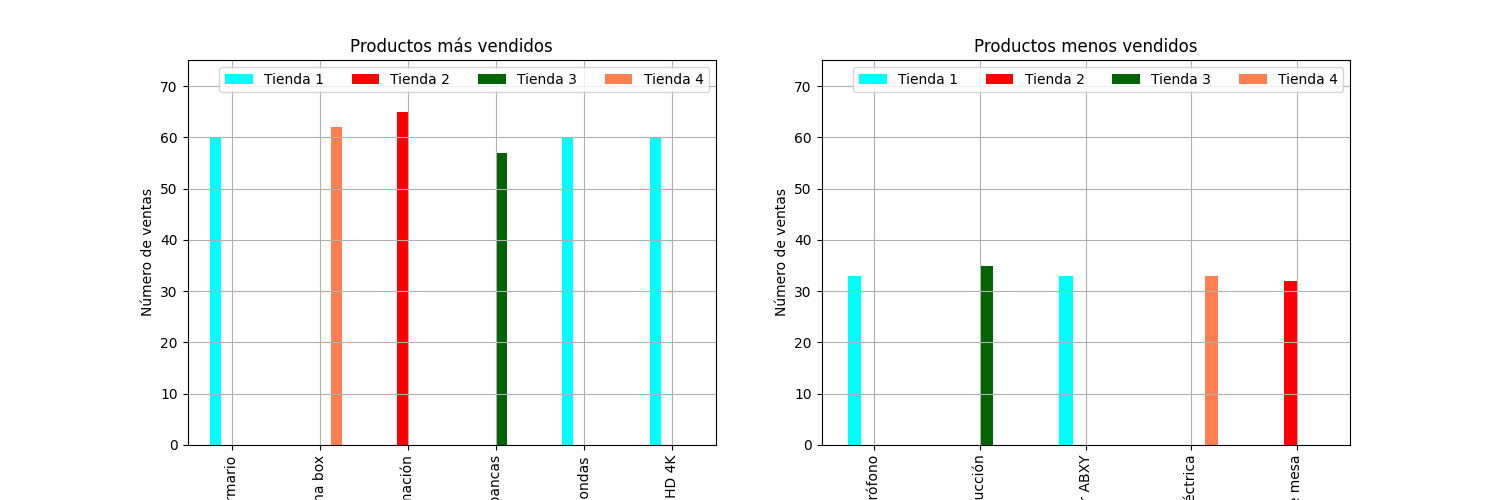

5. Logística y Costos de Envío
El análisis del costo promedio de envío revela una correlación directa con el volumen de facturación. La Tienda 1 registra los costos logísticos más elevados, mientras que la Tienda 4 presenta los más bajos. Este comportamiento confirma que el incremento en las transacciones impacta proporcionalmente en los gastos operativos de distribución.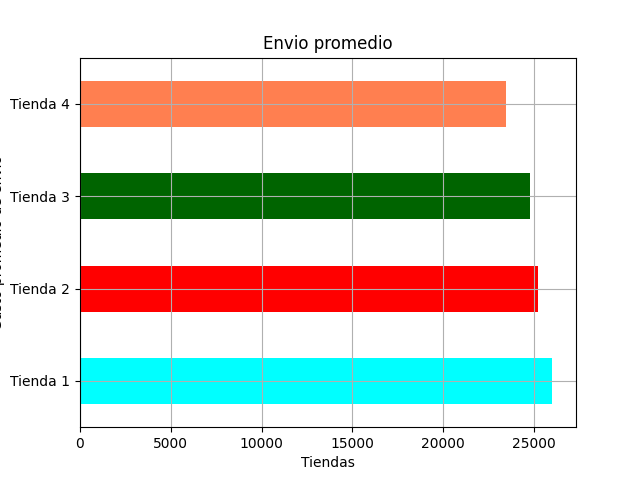